In [1]:
import numpy as np
import pandas as pd
import math
import networkx as nx

In [2]:
a = pd.read_csv("./datasets/a280.csv")
# a = pd.read_csv("./minidatasets/minitsp.csv")
# a = pd.read_csv("./datasets/xql662.csv")
points = np.array(a[['x','y']])
inputsize = len(points)

In [3]:
# # distance matrix 만들기
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distance_matrix = np.sqrt(np.sum(diff ** 2, axis=-1))

In [4]:
distance_matrix += 1

In [5]:
# MST 찾기( 프림 알고리즘 사용)
import heapq
visited = [False] * len(points)
minheap = []
mstgraph = np.full( ( inputsize, inputsize ), np.inf)

# 0 추가
for x in range(inputsize):
    heapq.heappush(minheap, ( distance_matrix[0][x] , 0, x ) )
visited[ 0 ] = True

while minheap:
    Weight, From, To = heapq.heappop( minheap )
    if not visited[To]:
        visited[To] = True
        mstgraph[ From, To ] = Weight
        mstgraph[ To, From ] = Weight
        for x in range(inputsize):
            next_to, next_weight = x, distance_matrix[To][x]
            if not visited[ next_to ]:
                heapq.heappush( minheap, ( next_weight, To, next_to ) )

mstgraph

array([[        inf,         inf,         inf, ...,         inf,
                inf, 18.88854382],
       [        inf,         inf,         inf, ...,         inf,
                inf,  9.94427191],
       [        inf,         inf,         inf, ...,         inf,
        11.77032961, 11.        ],
       ...,
       [        inf,         inf,         inf, ...,         inf,
         9.94427191,         inf],
       [        inf,         inf, 11.77032961, ...,  9.94427191,
                inf,         inf],
       [18.88854382,  9.94427191, 11.        , ...,         inf,
                inf,         inf]])

In [6]:
# 홀수 degree 찾기
oddmat = np.full( ( inputsize, inputsize ), np.inf)

finite_mask = np.isfinite(mstgraph)              # inf가 아닌 값은 True
finite_count_per_row = finite_mask.sum(axis=1) # 각 행마다 inf가 아닌 값의 개수
odd_rows = np.where(finite_count_per_row % 2 == 1)[0]  # 개수가 홀수인 행 인덱스

print(odd_rows.tolist())

[0, 1, 4, 5, 7, 8, 12, 14, 15, 16, 17, 18, 19, 20, 31, 33, 34, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 57, 61, 62, 64, 66, 68, 74, 75, 77, 78, 80, 82, 83, 84, 88, 92, 93, 95, 96, 97, 98, 100, 103, 105, 106, 108, 111, 113, 115, 124, 127, 129, 130, 131, 133, 134, 135, 136, 137, 141, 142, 143, 145, 146, 147, 149, 150, 168, 171, 173, 177, 178, 180, 187, 188, 191, 192, 193, 200, 207, 220, 230, 231, 232, 234, 235, 236, 239, 240, 242, 244, 245, 247, 249, 255, 263, 264, 266, 267, 268, 269, 275, 277, 278, 279]


In [7]:
# minimum weight perfect matching Blossom 알고리즘
graph = nx.from_numpy_array(distance_matrix)
print(graph)
mst = nx.minimum_spanning_tree(graph, weight='weight')
print(graph)
print(mst)
total_weight = mst.size(weight='weight')
print("MST 총 가중치:", total_weight)

Graph with 280 nodes and 39340 edges
Graph with 280 nodes and 39340 edges
Graph with 280 nodes and 279 edges
MST 총 가중치: 2717.566740962225


In [8]:
oddnodeindex = [n for n, d in mst.degree() if d % 2 == 0]
oddnodeindex
oddnode = graph.copy()
oddnode.remove_nodes_from(oddnodeindex)
print(graph)

Graph with 280 nodes and 39340 edges


In [9]:
a = []
for x in oddnode.nodes(data=True):
    a.append(x[0])

a

[0,
 1,
 4,
 5,
 7,
 8,
 12,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 31,
 33,
 35,
 36,
 37,
 43,
 44,
 45,
 46,
 47,
 48,
 50,
 51,
 52,
 53,
 54,
 55,
 57,
 63,
 64,
 66,
 68,
 74,
 75,
 77,
 78,
 80,
 82,
 83,
 84,
 88,
 92,
 93,
 95,
 96,
 97,
 98,
 100,
 103,
 105,
 106,
 108,
 111,
 113,
 115,
 117,
 124,
 127,
 129,
 130,
 131,
 133,
 134,
 135,
 136,
 137,
 141,
 142,
 143,
 145,
 146,
 147,
 149,
 150,
 168,
 171,
 173,
 177,
 178,
 180,
 187,
 188,
 191,
 192,
 193,
 200,
 207,
 220,
 230,
 231,
 232,
 234,
 235,
 236,
 239,
 240,
 242,
 244,
 245,
 247,
 249,
 255,
 263,
 264,
 266,
 267,
 268,
 269,
 275,
 277,
 278,
 279]

In [10]:
matching = nx.algorithms.matching.min_weight_matching( oddnode, weight='weight' )

In [11]:
print(matching)
sum =0
sum+= distance_matrix[28][20]
sum+= distance_matrix[15][4]
sum+= distance_matrix[10][7]
sum+= distance_matrix[14][9]
sum+= distance_matrix[16][18]
print(sum)

sum =0
sum+= distance_matrix[28][20]
sum+= distance_matrix[15][7]
sum+= distance_matrix[10][4]
sum+= distance_matrix[14][9]
sum+= distance_matrix[16][18]
print(sum)

{(108, 103), (96, 95), (247, 255), (4, 0), (31, 124), (147, 146), (173, 171), (188, 187), (51, 50), (78, 77), (191, 192), (106, 105), (177, 150), (235, 234), (83, 82), (57, 63), (115, 117), (149, 137), (37, 36), (267, 135), (5, 275), (45, 46), (111, 113), (266, 136), (240, 242), (33, 35), (18, 19), (269, 133), (193, 200), (142, 143), (14, 12), (264, 263), (130, 129), (97, 98), (244, 239), (66, 68), (207, 220), (75, 74), (131, 17), (92, 93), (278, 277), (88, 80), (53, 52), (168, 100), (231, 232), (84, 64), (145, 141), (55, 54), (47, 48), (16, 15), (44, 43), (1, 279), (245, 249), (8, 7), (178, 180), (268, 134), (230, 236), (20, 127)}
160.19333749158722
167.39726364778687


In [12]:
multigraph = nx.MultiGraph()
multigraph.add_nodes_from(mst.nodes(data=True))
multigraph.add_edges_from(mst.edges(data=True))

for u,v in matching:
    w = graph[u][v]['weight']
    multigraph.add_edge( u, v, weight = w)

In [13]:
# G.edges(data=True)
circuit = nx.eulerian_circuit(multigraph, source=None)

In [14]:
path = []
visited=np.full( inputsize, False) # 비트마스킹으로 10001 이면 두개 원소 있는거임

for x in circuit:
    if not visited[x[0]]:
        path.append(x[0])
        visited[x[0]] = True



In [15]:
distsum = 0

prev = None
for x in path:
    if prev == None:
        prev = x
        continue
    distsum += graph.edges[(prev , x)]['weight']
    prev = x
distsum += graph.edges[(x , 0)]['weight']

In [16]:
distsum - inputsize

2975.114776582676

In [17]:
# a = pd.read_csv("./opt/a280.opt.tour")
# b = np.array( a['path'] )



# path = [  int(x) - 1 for x in b ]
# visited=np.full( inputsize, False) # 비트마스킹으로 10001 이면 두개 원소 있는거임

# distsum = 0

# prev = None
# for x in path:
#     if prev == None:
#         prev = x
#         continue
#     distsum += graph.edges[(prev , x)]['weight']
#     prev = x
# distsum += graph.edges[(x , 0)]['weight']

In [18]:
len(path)
len(a)
a
distsum - 280

2975.114776582676

In [19]:
opt_a280 = 2586.76964756316
opt_kz9976 = 1061882
opt_xql662 = 2513
opt_mona = 100000

In [20]:
matching

{(1, 279),
 (4, 0),
 (5, 275),
 (8, 7),
 (14, 12),
 (16, 15),
 (18, 19),
 (20, 127),
 (31, 124),
 (33, 35),
 (37, 36),
 (44, 43),
 (45, 46),
 (47, 48),
 (51, 50),
 (53, 52),
 (55, 54),
 (57, 63),
 (66, 68),
 (75, 74),
 (78, 77),
 (83, 82),
 (84, 64),
 (88, 80),
 (92, 93),
 (96, 95),
 (97, 98),
 (106, 105),
 (108, 103),
 (111, 113),
 (115, 117),
 (130, 129),
 (131, 17),
 (142, 143),
 (145, 141),
 (147, 146),
 (149, 137),
 (168, 100),
 (173, 171),
 (177, 150),
 (178, 180),
 (188, 187),
 (191, 192),
 (193, 200),
 (207, 220),
 (230, 236),
 (231, 232),
 (235, 234),
 (240, 242),
 (244, 239),
 (245, 249),
 (247, 255),
 (264, 263),
 (266, 136),
 (267, 135),
 (268, 134),
 (269, 133),
 (278, 277)}

In [21]:
sum = 0
for x,y in matching:
    sum += distance_matrix[x][y]
print(sum - len(odd_rows) )

676.0365223667203


In [22]:
newmatching = []
for x,y in matching:
    if x < y:
        newmatching.append((x,y))
    else:
        newmatching.append((y,x))
newmatching.sort( key=lambda x: x[0] )
newmatching

[(0, 4),
 (1, 279),
 (5, 275),
 (7, 8),
 (12, 14),
 (15, 16),
 (17, 131),
 (18, 19),
 (20, 127),
 (31, 124),
 (33, 35),
 (36, 37),
 (43, 44),
 (45, 46),
 (47, 48),
 (50, 51),
 (52, 53),
 (54, 55),
 (57, 63),
 (64, 84),
 (66, 68),
 (74, 75),
 (77, 78),
 (80, 88),
 (82, 83),
 (92, 93),
 (95, 96),
 (97, 98),
 (100, 168),
 (103, 108),
 (105, 106),
 (111, 113),
 (115, 117),
 (129, 130),
 (133, 269),
 (134, 268),
 (135, 267),
 (136, 266),
 (137, 149),
 (141, 145),
 (142, 143),
 (146, 147),
 (150, 177),
 (171, 173),
 (178, 180),
 (187, 188),
 (191, 192),
 (193, 200),
 (207, 220),
 (230, 236),
 (231, 232),
 (234, 235),
 (239, 244),
 (240, 242),
 (245, 249),
 (247, 255),
 (263, 264),
 (277, 278)]

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 예시 데이터: Nx2 크기의 좌표 배열
# points = np.array([[x1, y1], [x2, y2], ..., [xN, yN]])
# mstgraph = N×N 크기의 배열, 무한대(inf)가 아닌 값은 MST의 간선 가중치
# matching = {(u1, v1), (u2, v2), ..., (uk, vk)} 형태의 노드 쌍 집합

def plot_mst_and_matching(points, mstgraph, matching):
    plt.figure(figsize=(10, 8))
    
    # 점 위치 그리기
    plt.scatter(points[:, 0], points[:, 1], c='blue', label='Points')
    
    # # MST 간선 그리기 (녹색 실선)
    # for i in range(len(points)):
    #     for j in range(i + 1, len(points)):
    #         if np.isfinite(mstgraph[i, j]):
    #             xi, yi = points[i]
    #             xj, yj = points[j]
    #             plt.plot([xi, xj], [yi, yj], c='green', linewidth=1)
    
    # 매칭 간선 그리기 (빨간 점선)
    for u, v in matching:
        xu, yu = points[u]
        xv, yv = points[v]
        plt.plot([xu, xv], [yu, yv], c='red', linestyle='--', linewidth=1.5)
    
    plt.title('MST and Minimum Weight Matching')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend(loc='best')
    plt.grid(True)
    plt.axis('equal')  # 가로세로 비율 동일
    plt.show()

# 함수 호출 예시
# plot_mst_and_matching(points, mstgraph, matching)


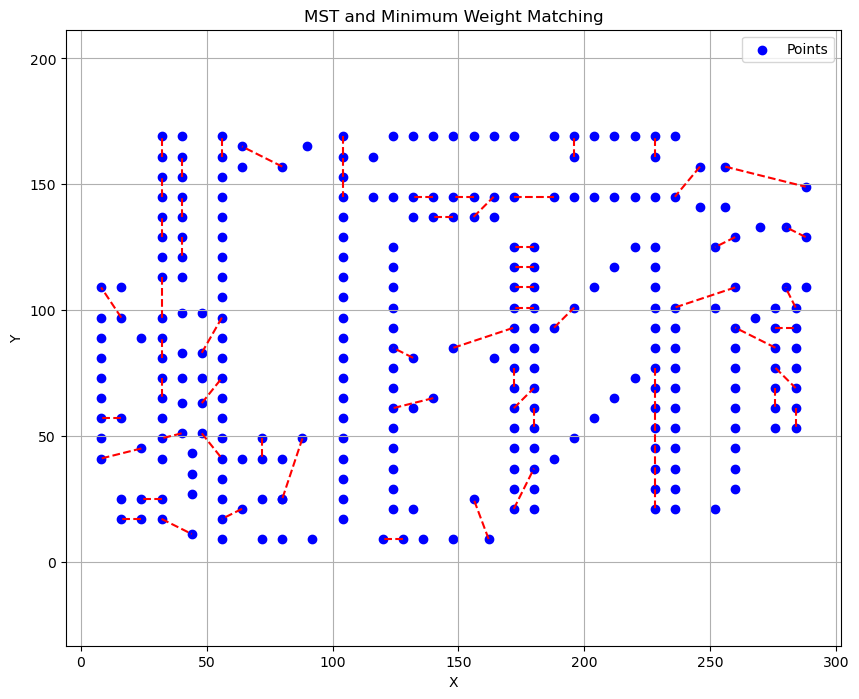

In [24]:
plot_mst_and_matching(points, mstgraph, matching)